# Clustering Analysis Using K-Means and K-Medoids Algorithms
**Name:** Umama Azhar

**Course:** MSCS 634 - Advanced Big Data and Data Mining

**Lab:** Lab 3 - Clustering Analysis Using K-Means and K-Medoids Algorithms

## Step 1: Load and Prepare the Dataset

In [16]:
## Loading the Wine dataset and looking at its structure:
# number of samples/features, feature names, and class distribution
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler


wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)

print("Shape:", df.shape)
print("\nFeatures:", wine.feature_names)
print("\nClass names:", wine.target_names)
print("\nClass distribution:", np.bincount(y))
df.describe().round(2)

Shape: (178, 13)

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class names: ['class_0' 'class_1' 'class_2']

Class distribution: [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


**Observation:** The dataset has 178 samples and 13 features. The classes are fairly balanced (59 / 71 / 48). The `describe()` table shows very different scales, for example proline averages about 747 while hue averages about 0.96. Distance-based clustering would be dominated by proline unless I scale the data.

### Standardization (z-score)
Each feature is rescaled to mean 0 and standard deviation 1 so that no single feature dominates the distance calculations.

In [17]:
## Z-score normalization: (value - mean) / std for every feature
# Afterwards, all features should have mean ~0 and std = 1
X_scaled = StandardScaler().fit_transform(X)

print("Means after scaling:", X_scaled.mean(axis=0).round(2))
print("Std devs after scaling:", X_scaled.std(axis=0).round(2))

Means after scaling: [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Std devs after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Observation:** All 13 features now have a mean of about 0 and a standard deviation of 1, so they contribute equally to clustering.

## Step 2: K-Means Clustering (k = 3)
K-Means places 3 centroids, assigns each wine to its nearest centroid, and moves each centroid to the average of its group until nothing changes. I use k = 3 because the dataset has 3 wine types.

In [18]:
# Fitting K-Means with k=3 (n_init=10 tries 10 random starts and keeps the best)
# Then scoring it:
#   Silhouette = how tight and well separated the clusters are (higher is better)
#   ARI = how well the clusters match the true wine types (1 = perfect, 0 = random)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means cluster sizes:", np.bincount(kmeans_labels))
print("Silhouette Score:", round(kmeans_sil, 3))
print("ARI:", round(kmeans_ari, 3))

K-Means cluster sizes: [65 51 62]
Silhouette Score: 0.285
ARI: 0.897


C:\Users\Umama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


**Observation:** K-Means produced clusters of sizes 65 / 51 / 62, close to the true 59 / 71 / 48. The ARI of 0.897 means it recovered the real wine types very well. The Silhouette Score of 0.285 is modest, meaning the clusters overlap somewhat at their edges.

## Step 3: K-Medoids Clustering (k = 3)
K-Medoids is like K-Means, but each cluster center (medoid) must be an actual wine from the dataset. `scikit-learn-extra` would not install on my Windows setup because it needs the Microsoft C++ compiler, so I implemented the PAM (Partitioning Around Medoids) algorithm myself using numpy.

In [19]:
# PAM K-Medoids implemented from scratch:
# 1. Computing the distance between every pair of wines
# 2. Picking 3 starting wines as medoids
# 3. Trying to swap each medoid with every other wine
# 4. Keeping the swap that lowers total distance the most; stopping when no swap helps
# 5. Assigning every wine to its nearest medoid
from sklearn.metrics import pairwise_distances

# Distance between every pair of wines (178 x 178)
D = pairwise_distances(X_scaled)

def pam_kmedoids(D, k, max_iter=100):
    n = D.shape[0]

    # Start: first center is the wine closest to all others,
    # then adding centers that reduce the total distance the most
    medoids = [int(np.argmin(D.sum(axis=1)))]
    while len(medoids) < k:
        nearest = D[:, medoids].min(axis=1)
        gains = np.maximum(nearest[:, None] - D, 0).sum(axis=0)
        gains[medoids] = -1
        medoids.append(int(np.argmax(gains)))

    # Swap step: keep making the best swap until none helps
    cost = D[:, medoids].min(axis=1).sum()
    for _ in range(max_iter):
        best_cost, best_slot, best_wine = cost, None, None
        for slot in range(k):
            for wine_idx in range(n):
                if wine_idx in medoids:
                    continue
                trial = medoids.copy()
                trial[slot] = wine_idx
                trial_cost = D[:, trial].min(axis=1).sum()
                if trial_cost < best_cost:
                    best_cost, best_slot, best_wine = trial_cost, slot, wine_idx
        if best_slot is None:
            break
        cost = best_cost
        medoids[best_slot] = best_wine

    labels = D[:, medoids].argmin(axis=1)
    return np.array(medoids), labels

medoid_idx, kmedoids_labels = pam_kmedoids(D, k=3)

kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("Medoid wine indices:", medoid_idx)
print("K-Medoids cluster sizes:", np.bincount(kmedoids_labels))
print("Silhouette Score:", round(kmedoids_sil, 3))
print("ARI:", round(kmedoids_ari, 3))

Medoid wine indices: [ 35 148 106]
K-Medoids cluster sizes: [74 49 55]
Silhouette Score: 0.268
ARI: 0.741


**Observation:** K-Medoids produced clusters of sizes 74 / 49 / 55, with a Silhouette Score of 0.268 and an ARI of 0.741. Both scores are lower than K-Means. The cluster sizes drift further from the true class sizes, and one cluster is larger than any real wine type.

## Step 4: Visualize and Compare
The data has 13 dimensions, so I have used PCA to reduce it to 2 dimensions for plotting only. The clustering itself used all 13 features. Red X marks show the centroids (K-Means) and medoids (K-Medoids).

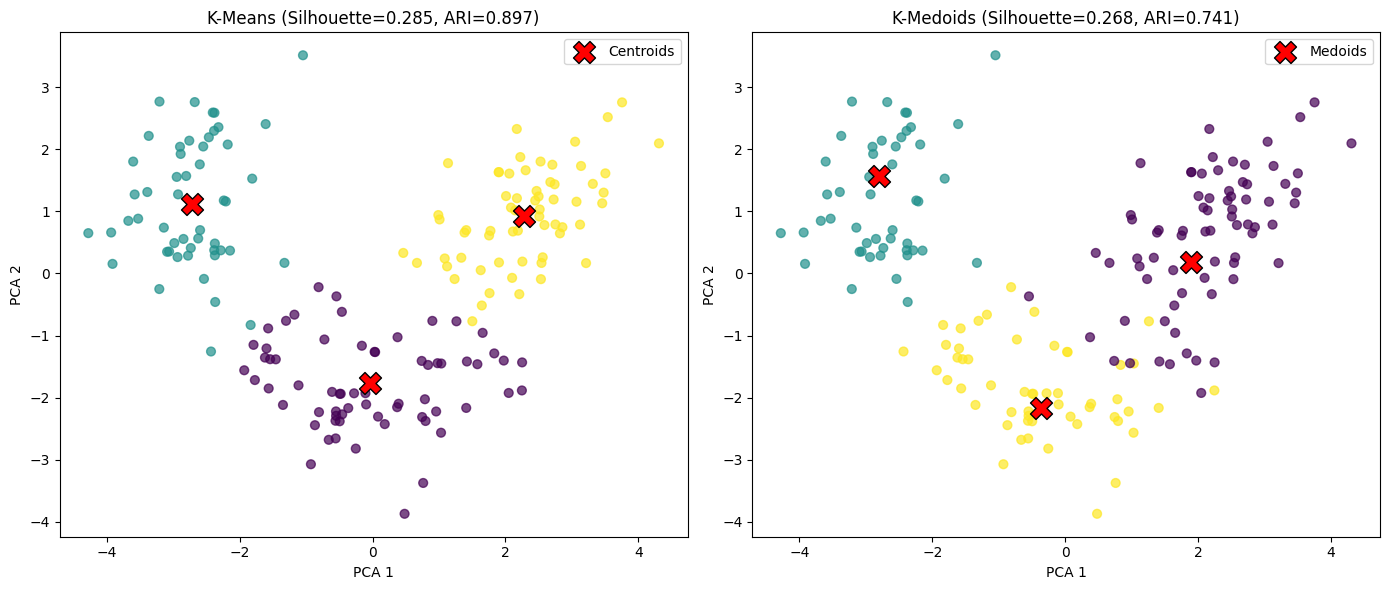

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA reduces 13 features to 2 so the clusters can be drawn 
# Centroids/medoids are projected into the same 2D space and marked with red X's

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# Moving the centers into the same 2D picture
kmeans_centers_2d = pca.transform(kmeans.cluster_centers_)
medoid_centers_2d = pca.transform(X_scaled[medoid_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, cmap="viridis", s=40, alpha=0.7)
axes[0].scatter(kmeans_centers_2d[:, 0], kmeans_centers_2d[:, 1],
                c="red", marker="X", s=250, edgecolors="black", label="Centroids")
axes[0].set_title(f"K-Means (Silhouette={kmeans_sil:.3f}, ARI={kmeans_ari:.3f})")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].legend()

# K-Medoids
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=kmedoids_labels, cmap="viridis", s=40, alpha=0.7)
axes[1].scatter(medoid_centers_2d[:, 0], medoid_centers_2d[:, 1],
                c="red", marker="X", s=250, edgecolors="black", label="Medoids")
axes[1].set_title(f"K-Medoids (Silhouette={kmedoids_sil:.3f}, ARI={kmedoids_ari:.3f})")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## Analysis: K-Means vs. K-Medoids

| Method | Silhouette Score | ARI |
|---|---|---|
| K-Means | 0.285 | 0.897 |
| K-Medoids | 0.268 | 0.741 |

**Which algorithm produced better-defined clusters?**
K-Means did. It had a higher Silhouette Score (0.285 vs. 0.268), meaning its clusters were slightly tighter and better separated. It also matched the true wine classes much better (ARI 0.897 vs. 0.741).

**Differences in cluster shapes and positioning:**
Both methods found a similar cluster in the upper left. The difference is in the border between the other two clusters. K-Medoids shifted that border, so one cluster stretched further along the bottom and several wines in the middle were assigned differently than in K-Means. K-Means centroids are averages and can sit between data points, while K-Medoids centers are always real wines from the dataset.

**When is each preferable?**
K-Means is a good choice when the data is clean, the clusters are roughly round, and speed matters on large datasets, as it was here. K-Medoids is preferable when the data has outliers or noise, because a real data point as the center is not pulled by extreme values. It is also useful when the center needs to be an actual, interpretable example, or when using a distance other than Euclidean.